# Quality Assessment
Now it's your turn. Follow the steps on the platform and use what you've learnt to see how reliable the data is.

In [170]:
import pandas as pd

Load our cleaned DataFrames

In [171]:
# orders_cl.csv
url = "https://drive.google.com/file/d/1QiWLCP_60mpXEYS6A1YEH3S0Whg288xy/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1hu2Kh3rAOQVC0gGLQN8Zs_HMboVXlu2B/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1IPnKYLSnrST0HBZMeSeNrhFfWU31QvwB/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

In [172]:
products_cl

,sku,name,desc,price,in_stock,type
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364
...,...,...,...,...,...,...
9987,BEL0376,Belkin Travel Support Apple Watch Black,compact and portable stand vertically or horiz...,29.99,1,12282
9988,THU0060,"Enroute Thule 14L Backpack MacBook 13 ""Black",Backpack with capacity of 14 liter compartment...,69.95,1,1392
9989,THU0061,"Enroute Thule 14L Backpack MacBook 13 ""Blue",Backpack with capacity of 14 liter compartment...,69.95,1,1392
9990,THU0062,"Enroute Thule 14L Backpack MacBook 13 ""Red",Backpack with capacity of 14 liter compartment...,69.95,0,1392


In [173]:
orderlines_cl

,id,id_order,product_id,product_quantity,sku,unit_price,date
0,1119109,299539,0,1,OTT0133,18.99,2017-01-01 00:07:19
1,1119110,299540,0,1,LGE0043,399.00,2017-01-01 00:19:45
2,1119111,299541,0,1,PAR0071,474.05,2017-01-01 00:20:57
3,1119112,299542,0,1,WDT0315,68.39,2017-01-01 00:51:40
4,1119113,299543,0,1,JBL0104,23.74,2017-01-01 01:06:38
...,...,...,...,...,...,...,...
216245,1650199,527398,0,1,JBL0122,42.99,2018-03-14 13:57:25
216246,1650200,527399,0,1,PAC0653,141.58,2018-03-14 13:57:34
216247,1650201,527400,0,2,APP0698,9.99,2018-03-14 13:57:41
216248,1650202,527388,0,1,BEZ0204,19.99,2018-03-14 13:58:01


In [174]:
orders_cl

,order_id,created_date,total_paid,state
0,241319,2017-01-02 13:35:40,44.99,Cancelled
1,241423,2017-11-06 13:10:02,136.15,Completed
2,242832,2017-12-31 17:40:03,15.76,Completed
3,243330,2017-02-16 10:59:38,84.98,Completed
4,243784,2017-11-24 13:35:19,157.86,Cancelled
...,...,...,...,...
226899,527397,2018-03-14 13:56:38,42.99,Place Order
226900,527398,2018-03-14 13:57:25,42.99,Shopping Basket
226901,527399,2018-03-14 13:57:34,141.58,Shopping Basket
226902,527400,2018-03-14 13:57:41,19.98,Shopping Basket


## 1.&nbsp; Define Pandas display format

In [175]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

## 2.&nbsp; Exclude unwanted orders

In [176]:
merge_df=orders_cl.merge(orderlines_cl, left_on='order_id', right_on="id_order", how='inner')

In [177]:
merge_df=merge_df.loc[merge_df['state'] == 'Completed']

## 3.&nbsp; Exclude orders with unknown products


In [178]:
merge_df.info()

<class 'pandas.DataFrame'>
Index: 56714 entries, 1 to 215772
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          56714 non-null  int64  
 1   created_date      56714 non-null  str    
 2   total_paid        56714 non-null  float64
 3   state             56714 non-null  str    
 4   id                56714 non-null  int64  
 5   id_order          56714 non-null  int64  
 6   product_id        56714 non-null  int64  
 7   product_quantity  56714 non-null  int64  
 8   sku               56714 non-null  str    
 9   unit_price        56714 non-null  float64
 10  date              56714 non-null  str    
dtypes: float64(2), int64(5), str(4)
memory usage: 5.2 MB


In [179]:
merge_df["valid_product"] = merge_df["sku"].isin(products_cl["sku"])

In [180]:
merge_df["valid_product"].value_counts()

valid_product
True     55320
False     1394
Name: count, dtype: int64

In [181]:
merge_df["valid_order"]=merge_df.groupby("order_id")["valid_product"].transform('prod')

In [83]:
merge_df["valid_order"].value_counts()

valid_order
1    54324
0     2390
Name: count, dtype: int64

In [84]:
merge_df=merge_df.loc[merge_df['valid_order'] == True]

In [85]:
merge_df.drop(columns=["valid_product", "valid_order"], inplace=True)

In [86]:
merge_df.info()

<class 'pandas.DataFrame'>
Index: 54324 entries, 1 to 215772
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          54324 non-null  int64  
 1   created_date      54324 non-null  str    
 2   total_paid        54324 non-null  float64
 3   state             54324 non-null  str    
 4   id                54324 non-null  int64  
 5   id_order          54324 non-null  int64  
 6   product_id        54324 non-null  int64  
 7   product_quantity  54324 non-null  int64  
 8   sku               54324 non-null  str    
 9   unit_price        54324 non-null  float64
 10  date              54324 non-null  str    
dtypes: float64(2), int64(5), str(4)
memory usage: 5.0 MB


## 4.&nbsp; Explore the revenue from different tables

#### Step 1:
Create the `unit_price_total` as `orderlines.unit_price` * `orderlines.product_quantity`

In [87]:
merge_df["unit_price_total"] = merge_df["unit_price"] * merge_df["product_quantity"]

In [141]:
merge_df

,order_id,created_date,total_paid,state,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_total,price_difference,price_bin
1,241423,2017-11-06 13:10:02,136.15,Completed,1398738,241423,0,1,LAC0212,129.16,2017-11-06 12:47:20,129.16,6.99,"(-78.542, 7.915]"
2,242832,2017-12-31 17:40:03,15.76,Completed,1529178,242832,0,1,PAR0074,10.77,2017-12-31 17:26:40,10.77,4.99,"(-78.542, 7.915]"
3,243330,2017-02-16 10:59:38,84.98,Completed,1181923,243330,0,1,OWC0074,77.99,2017-02-15 17:07:44,77.99,6.99,"(-78.542, 7.915]"
5,245275,2017-06-28 11:35:37,149.00,Completed,1276706,245275,0,1,TAD0007,149.00,2017-06-28 11:12:30,149.00,0.00,"(-78.542, 7.915]"
6,245595,2017-01-21 12:52:47,112.97,Completed,1154394,245595,0,2,PAC1561,52.99,2017-01-21 12:49:00,105.98,6.99,"(-78.542, 7.915]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215704,527042,2018-03-14 11:47:50,18.98,Completed,1649446,527042,0,1,APP0927,13.99,2018-03-14 11:42:38,13.99,4.99,"(-78.542, 7.915]"
215734,527070,2018-03-14 11:50:48,24.97,Completed,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,19.98,4.99,"(-78.542, 7.915]"
215737,527074,2018-03-14 11:51:42,24.97,Completed,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,19.98,4.99,"(-78.542, 7.915]"
215758,527096,2018-03-14 11:58:40,34.96,Completed,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,29.97,4.99,"(-78.542, 7.915]"


#### Step 2:
Group by `id_order`, summarising by the sum of `unit_price_total`

In [138]:
unp_df=merge_df.groupby("id_order").agg({"unit_price_total": "sum"}).copy()

,unit_price_total
id_order,
241423,129.16
242832,10.77
243330,77.99
245275,149.00
245595,105.98
...,...
527042,13.99
527070,19.98
527074,19.98


### What is the average difference between `total_paid` and `unit_price_total`?

In [144]:
unp_df["total_paid"]=merge_df.groupby("id_order").agg({"total_paid": "sum"}).copy()

In [145]:
unp_df["price_difference"] = unp_df["total_paid"]-unp_df["unit_price_total"]

In [186]:
unp_df["price_difference"].value_counts()

price_difference
0.00       8395
6.99       3573
4.99       2767
4.99       2104
4.99       1998
           ... 
484.89        1
226.95        1
564.94        1
2613.87       1
42.97         1
Name: count, Length: 6591, dtype: int64

In [187]:
unp_df["price_difference"].describe()

count   41701.00
mean       98.92
std       420.81
min      -165.00
25%         3.99
50%         4.99
75%         6.99
max     15230.09
Name: price_difference, dtype: float64

### What is the distribution of these differences?

In [128]:
#merge_df['price_bin'] = pd.cut(merge_df['price_difference'], bins=list(range(int(merge_df['price_difference'].min()), int(merge_df['price_difference'].max()) + 5, 5)))
#merge_df.groupby("price_bin").agg({"price_difference": ["count", "mean"]})


In [149]:
unp_df['price_bin'] = pd.cut(unp_df['price_difference'], bins=50)
unp_df.groupby('price_bin')['unit_price_total'].count()

price_bin
(-180.395, 142.902]       36331
(142.902, 450.804]         2910
(450.804, 758.705]         1034
(758.705, 1066.607]         637
(1066.607, 1374.509]        240
(1374.509, 1682.411]        152
(1682.411, 1990.313]        112
(1990.313, 2298.214]         63
(2298.214, 2606.116]         49
(2606.116, 2914.018]         39
(2914.018, 3221.92]          32
(3221.92, 3529.822]          17
(3529.822, 3837.723]         12
(3837.723, 4145.625]          5
(4145.625, 4453.527]          9
(4453.527, 4761.429]          4
(4761.429, 5069.331]         14
(5069.331, 5377.232]          3
(5377.232, 5685.134]          6
(5685.134, 5993.036]          3
(5993.036, 6300.938]          3
(6300.938, 6608.84]           2
(6608.84, 6916.741]           4
(6916.741, 7224.643]          2
(7532.545, 7840.447]          1
(7840.447, 8148.349]          1
(8764.152, 9072.054]          2
(9379.956, 9687.858]          2
(9995.759, 10303.661]         1
(10919.465, 11227.367]        1
(12151.072, 12458.974]        

In [159]:
unp_df.sort_values(by='price_difference', ascending=False).head(10)

,unit_price_total,total_paid,price_difference,price_bin
id_order,,,,
440093,1903.75,17133.84,15230.09,"(14922.188, 15230.09]"
449404,1605.84,16058.40,14452.56,"(14306.385, 14614.286]"
364355,1738.91,15650.10,13911.19,"(13690.581, 13998.483]"
423205,2308.29,16158.17,13849.88,"(13690.581, 13998.483]"
520342,1149.86,14948.18,13798.32,"(13690.581, 13998.483]"
316729,1509.87,15098.60,13588.73,"(13382.679, 13690.581]"
307948,2169.92,15189.44,13019.52,"(12766.876, 13074.777]"
498539,3143.07,15750.45,12607.38,"(12458.974, 12766.876]"
381251,3069.00,15345.00,12276.00,"(12151.072, 12458.974]"


In [155]:
#print(f"The proportion of differences explainable by freight is {unp_df.loc[unp_df['price_difference'].between(-100, 0),:]['id_order'].count()/unp_df['id_order'].count():.2%}")

### Can all the differences be explained by shipping costs? If not, what are other plausible explanations?

<Axes: >

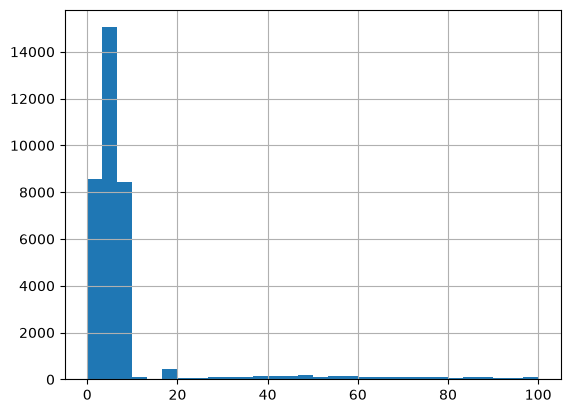

In [156]:
unp_df['price_difference'].hist(bins=30, range=(0, 100))

### If there are differences that you can’t explain: what should you do with these orders?

Certain outliers definitely seems to be some kind of data entry issue - i.e look at the ones below. Here one could dig a bit more in the original data.

In [160]:
unp_df.sort_values(by='price_difference', ascending=False).head(10)

,unit_price_total,total_paid,price_difference,price_bin
id_order,,,,
440093,1903.75,17133.84,15230.09,"(14922.188, 15230.09]"
449404,1605.84,16058.40,14452.56,"(14306.385, 14614.286]"
364355,1738.91,15650.10,13911.19,"(13690.581, 13998.483]"
423205,2308.29,16158.17,13849.88,"(13690.581, 13998.483]"
520342,1149.86,14948.18,13798.32,"(13690.581, 13998.483]"
316729,1509.87,15098.60,13588.73,"(13382.679, 13690.581]"
307948,2169.92,15189.44,13019.52,"(12766.876, 13074.777]"
498539,3143.07,15750.45,12607.38,"(12458.974, 12766.876]"
381251,3069.00,15345.00,12276.00,"(12151.072, 12458.974]"


In [168]:
test=unp_df.sort_values(by='price_difference', ascending=False).head(10).copy()
test["corrected"]=test['total_paid'] / 10
test["new difference"]=test["unit_price_total"]-test["corrected"]
test

,unit_price_total,total_paid,price_difference,price_bin,corrected,new difference
id_order,,,,,,
440093,1903.75,17133.84,15230.09,"(14922.188, 15230.09]",1713.38,190.37
449404,1605.84,16058.40,14452.56,"(14306.385, 14614.286]",1605.84,0.00
364355,1738.91,15650.10,13911.19,"(13690.581, 13998.483]",1565.01,173.90
423205,2308.29,16158.17,13849.88,"(13690.581, 13998.483]",1615.82,692.47
520342,1149.86,14948.18,13798.32,"(13690.581, 13998.483]",1494.82,-344.96
316729,1509.87,15098.60,13588.73,"(13382.679, 13690.581]",1509.86,0.01
307948,2169.92,15189.44,13019.52,"(12766.876, 13074.777]",1518.94,650.98
498539,3143.07,15750.45,12607.38,"(12458.974, 12766.876]",1575.05,1568.03
381251,3069.00,15345.00,12276.00,"(12151.072, 12458.974]",1534.50,1534.50


Ok so the canonical solution here from WBS is apparently to use the "Outlier" thingy from the chapter on statistics in the primer to cut values.

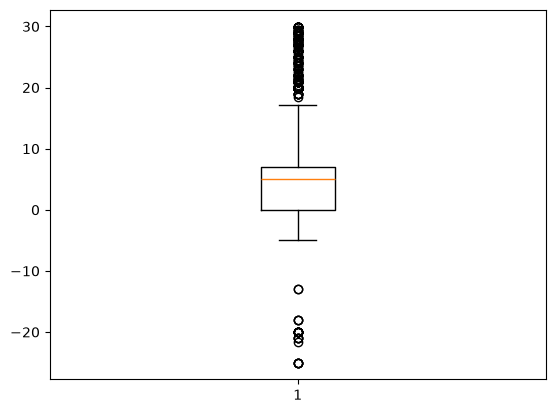

: 

In [ ]:
import matplotlib.pyplot as plt
subset = unp_df.loc[unp_df["price_difference"].between(-30, 30), "price_difference"]
plt.boxplot(subset)
plt.show()

## 5.&nbsp; Become confident about your dataset

Let's hear your thoughts about what you discovered.

In [133]:
# your thoughts & code here

Do not forget to download your quality controlled DataFrames

In [ ]:
#from google.colab import files

#orders_quality_controlled.to_csv("orders_qu.csv", index=False)
#files.download("orders_qu.csv")

#orderlines_quality_controlled.to_csv("orderlines_qu.csv", index=False)
#files.download("orderlines_qu.csv")

ModuleNotFoundError: No module named 'google'